In [1]:
from model_complex import InfluenzaData
from prediction_module.predictor import PredictionGenerator
%load_ext autoreload
%autoreload 2

c:\Users\105\GitHub\Influenza_bulletin\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
!uv pip install .

"uv" �� ���� ����७��� ��� ���譥�
��������, �ᯮ��塞�� �ணࠬ��� ��� ������ 䠩���.


In [2]:
import pickle
city = 'russia'
save_path_folder='report_rscf/'
#epid_data = InfluenzaData(city, begin_year=2026, begin_week=35, end_year=2026, end_week=36)

'''


with open("epid_data_25_26.pkl", "wb") as file:
    pickle.dump(epid_data, file)
'''
#epid_data = InfluenzaData(city, begin_year=2025, begin_week=35, end_year=2026, end_week=21)
with open("epid_data_25_26.pkl", "rb") as file:
    epid_data = pickle.load(file)
epid_data.begin_week


35

In [15]:
epid_data = InfluenzaData(city, begin_year=2025, begin_week=35, end_year=2026, end_week=37)

https://db.influenza.spb.ru/scripts/report/rmancgi.exe?reportname=get_csv&id=aripcr&byear=2025&bweek=35&eyear=2026&eweek=37&district=0&auth=7e283896cf78e49c321dc60fab2850745a25215b621f600f648424d242a78c4a


[autoreload of cutils_ext failed: Traceback (most recent call last):
  File "c:\Users\105\GitHub\Influenza_bulletin\.venv\Lib\site-packages\IPython\extensions\autoreload.py", line 325, in check
    superreload(m, reload, self.old_objects)
  File "c:\Users\105\GitHub\Influenza_bulletin\.venv\Lib\site-packages\IPython\extensions\autoreload.py", line 580, in superreload
    module = reload(module)
             ^^^^^^^^^^^^^^
  File "D:\Programs\Anaconda\Lib\importlib\__init__.py", line 130, in reload
    raise ModuleNotFoundError(f"spec not found for the module {name!r}", name=name)
ModuleNotFoundError: spec not found for the module 'cutils_ext'
]
Initializing SMC sampler...
Sampling 4 chains in 4 jobs


c:\Users\105\GitHub\Influenza_bulletin\.venv\Lib\site-packages\rich\live.py:256: UserWarning: install "ipywidgets" 
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Папка уже существует: report_rscf/2026_09_16\mcmc


c:\Users\105\GitHub\Influenza_bulletin\.venv\Lib\site-packages\arviz\data\base.py:272: UserWarning: More chains (4) than draws (1). Passed array should have shape (chains, draws, *shape)
  warnings.warn(


                     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  \
log_ab_combined[0] -0.899  0.034  -0.960   -0.832        0.0      0.0   
log_ratio          -0.836  0.035  -0.901   -0.771        0.0      0.0   
alpha[0]            0.420  0.012   0.398    0.442        0.0      0.0   
beta[0]             0.970  0.020   0.935    1.000        0.0      0.0   

                    ess_bulk  ess_tail  r_hat  
log_ab_combined[0]   12117.0   11929.0    1.0  
log_ratio            11991.0   11359.0    1.0  
alpha[0]             12190.0   11087.0    1.0  
beta[0]              11779.0   11133.0    1.0  
ModelParams(alpha=[np.float64(0.4199658309509927)], beta=[np.float64(0.9722375203265838)], population_size=np.int64(5501915), initial_infectious=[100])
300 len ciparams
ModelParams(alpha=[np.float64(0.4199658309509927)], beta=[np.float64(0.9722375203265838)], population_size=np.int64(5501915), initial_infectious=[100])
55 55
49 [84, 85, 86, 87, 88, 89, 90, 91, 92, 93]
300 len ciparams
ModelP

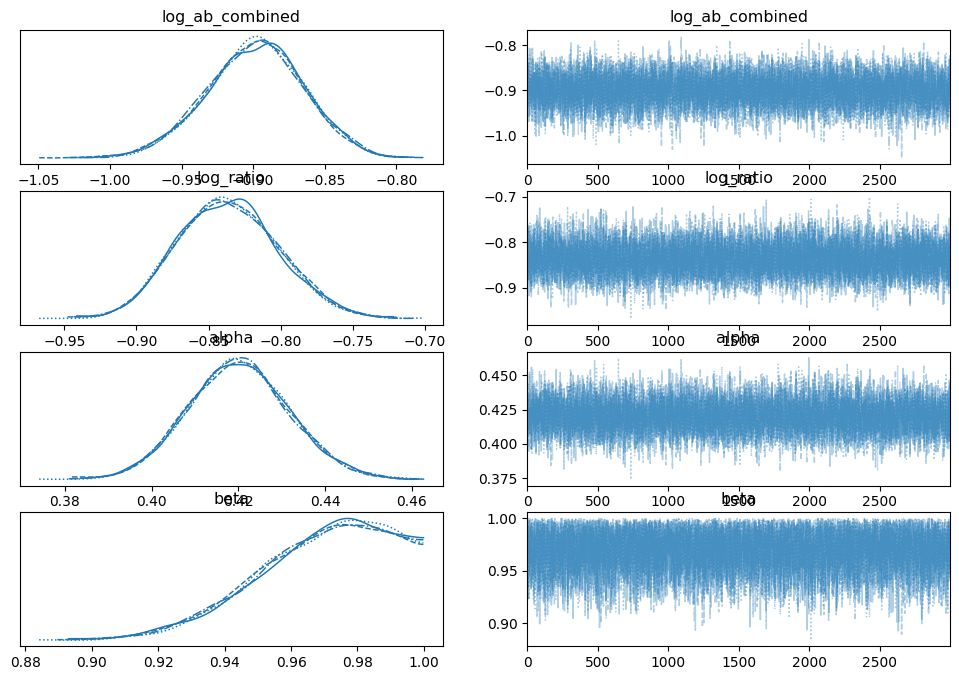

<Figure size 1333.33x440 with 0 Axes>

<Figure size 1333.33x440 with 0 Axes>

In [28]:
predictor = PredictionGenerator(epid_data=epid_data,
                                    city=city,
                                    save_path=save_path_folder)


method = 'mcmc'
type = 'total'
# based on expected minimum relative error (10-15%)
eps = 0.15  
draws = 3000
chains = 4


forecast_duration = 4
predictor.generate_forecasts(method=method,
                            type=type,
                            forecast_duration=forecast_duration,
                            epsilon_start=eps,
                            epsilon_end=eps,
                            epsilon_step=1,
                            n_trials=1,
                            sample=600, # choosing N lines for the final plot?
                            tune=400,#1000
                            draws=300,#1000
                            chains=4)# 6 from Dinara's ipynb

In [16]:
from plot_module.calibration.calibration_and_forecast import prepare_calibration_data,get_model_and_function
import numpy as np
# alpha*beta
method = 'mcmc'
type = 'total'
eps = 2
time_step = 'week'
forecast_duration = 4

# 1. Подготовка данных
data0, dur, plot_data = prepare_calibration_data(epid_data, type)
model, model_params, func_to_get_newly_data = get_model_and_function(epid_data, type)

coef_array_data = np.array(10000 / epid_data.returned_df["total_population"])

In [17]:
import pymc as pm
from model_complex import Calibration, FactoryModel, ModelParams

time_step = data0.attrs["time_step"]
data = data0.drop(columns=["datetime"]).to_numpy().T.flatten()

alpha_dim, beta_dim = model.params()
duration = len(data) // alpha_dim
get_newly_infected_base_on_time_step = model.get_daily_newly_infected

if time_step == "week":
    duration *= 7
    get_newly_infected_base_on_time_step = model.get_weekly_newly_infected

simulate_params = ModelParams(
    alpha=[0],
    beta=[0],
    population_size=model_params.population_size,
    initial_infectious=model_params.initial_infectious,
)

def simulation_func(rng, alpha, beta, size=None):
    simulate_params.alpha = alpha
    simulate_params.beta = beta

    model.simulate(params=simulate_params, modeling_duration=duration)
    res = get_newly_infected_base_on_time_step()
    return res

In [18]:
simulation_func(_, [0.4212], [0.98], size=None)

array([2.55202017e+02, 3.42993431e+02, 5.37670175e+02, 8.47044769e+02,
       1.33384974e+03, 2.09799643e+03, 3.29385258e+03, 5.15643569e+03,
       8.03584315e+03, 1.24351726e+04, 1.90340510e+04, 2.86513657e+04,
       4.20535081e+04, 5.94738186e+04, 7.97837258e+04, 9.96493062e+04,
       1.13700009e+05, 1.16773890e+05, 1.07334565e+05, 8.88024370e+04,
       6.71484982e+04, 4.73374368e+04, 3.17235675e+04, 2.05377050e+04,
       1.29981867e+04, 8.10838328e+03, 5.01242100e+03, 3.08118683e+03,
       1.88748609e+03, 1.15378926e+03, 7.04376022e+02, 4.29672687e+02,
       2.61975384e+02, 1.59681605e+02, 9.73130449e+01, 5.92979329e+01,
       3.61309177e+01, 2.20140894e+01, 1.34125599e+01, 8.17176838e+00,
       4.97870529e+00, 3.03329292e+00, 1.84803757e+00, 1.12591689e+00,
       6.85963998e-01, 4.17922713e-01, 2.54618773e-01, 1.55126053e-01,
       9.45102667e-02, 5.75802025e-02, 3.50806280e-02, 2.13728045e-02,
       1.30213394e-02, 7.93322542e-03, 4.83330196e-03])

Initializing SMC sampler...
Sampling 4 chains in 4 jobs


c:\Users\105\GitHub\Influenza_bulletin\.venv\Lib\site-packages\arviz\data\base.py:272: UserWarning: More chains (4) than draws (1). Passed array should have shape (chains, draws, *shape)
  warnings.warn(
C:\Users\105\AppData\Local\Temp\ipykernel_3256\341968448.py:96: UserWarning: The effect of Potentials on other parameters is ignored during posterior predictive sampling. This is likely to lead to invalid or biased predictive samples.
  idata.extend(pm.sample_posterior_predictive(idata, progressbar=False))
Sampling: [sim]


                     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  \
log_ab_combined[0] -0.931  0.085  -1.092   -0.776      0.001    0.001   
log_ratio          -0.803  0.084  -0.960   -0.641      0.001    0.001   
alpha[0]            0.421  0.030   0.364    0.476      0.000    0.000   
beta[0]             0.939  0.043   0.862    1.000      0.000    0.000   

                    ess_bulk  ess_tail  r_hat  
log_ab_combined[0]   11706.0   11763.0    1.0  
log_ratio            11603.0   11411.0    1.0  
alpha[0]             11719.0   11068.0    1.0  
beta[0]              11621.0   11381.0    1.0  


array([[<Axes: title={'center': 'log_ab_combined'}>,
        <Axes: title={'center': 'log_ab_combined'}>],
       [<Axes: title={'center': 'log_ratio'}>,
        <Axes: title={'center': 'log_ratio'}>],
       [<Axes: title={'center': 'alpha'}>,
        <Axes: title={'center': 'alpha'}>],
       [<Axes: title={'center': 'beta'}>,
        <Axes: title={'center': 'beta'}>]], dtype=object)

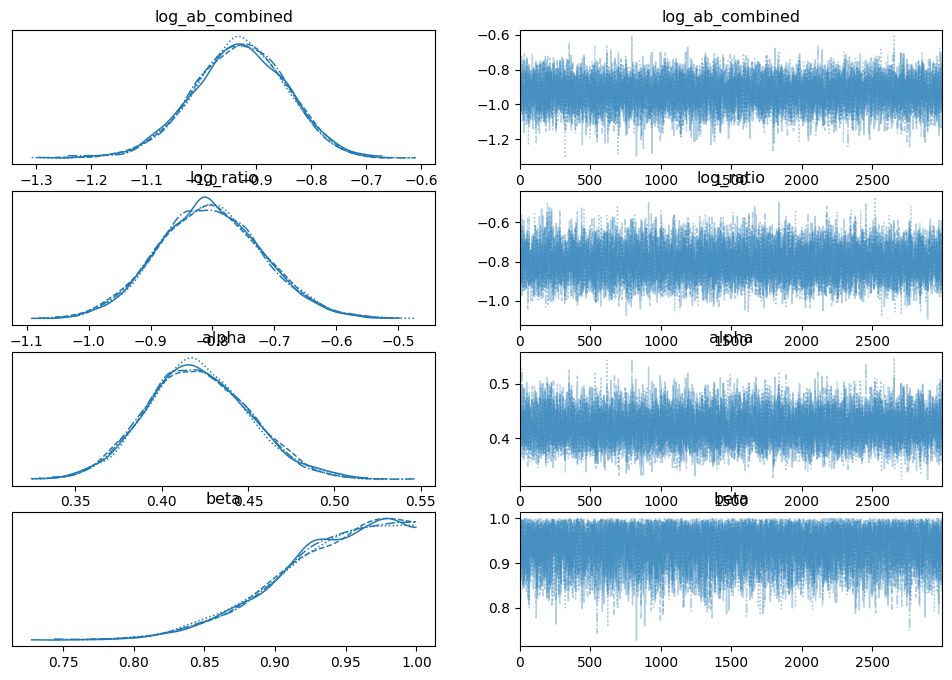

In [94]:
epsilon =  0.02  # 0.08 означает, что мы допускаем среднюю ошибку не более 8% от высоты пика
tune = 2000
draws = 3000 #SMC (Sequential Monte Carlo) значение draws — это количество параллельных частиц (populaton size).
chains = 4
old = False
smc = True

import pytensor.tensor as pt

# 1. Кастомная функция расстояния в лог-масштабе
def log_rmse_distance(obs_data, sim_data, epsilon=None, *args):
    sim_data_clipped = np.clip(sim_data, a_min=0, a_max=None)
    return np.sqrt(np.mean((np.log1p(obs_data) - np.log1p(sim_data_clipped)) ** 2))



with pm.Model() as pm_model:

    if old:
        #alpha = pm.Uniform(name="alpha", lower=0., upper=1., shape=(alpha_dim,))
        #alpha = pm.Normal(name="alpha", mu=0.42, sigma=0.5, shape=(alpha_dim,))
        #beta = pm.Uniform(name="beta", lower=0., upper=1., shape=(beta_dim,))
        #alpha = pm.HalfNormal("alpha", sigma=0.5, shape=(alpha_dim,))
    
        # 2. BETA БОЛЬШЕ НЕ СЭМПЛИРУЕТСЯ! Она строго привязана к alpha через вашу лучшую пропорцию
        # Коэффициент 2.3333 (0.98 / 0.42) гарантирует, что они всегда сохраняют идеальный баланс
        #beta = pm.Deterministic("beta", alpha * 2.33)
        #ratio_jitter = pm.Normal("ratio_jitter", mu=2.3, sigma=0.5)
        #beta = pm.Deterministic("beta", alpha * ratio_jitter)

        # 1. ПЕРВЫЙ ПАРАМЕТР: Произведение alpha * beta (строго от 0 до 1)
        ab_combined = pm.Uniform("ab_combined", lower=0.0, upper=1.0, shape=(alpha_dim,))
        
        # 2. ВТОРОЙ ПАРАМЕТР: Пропорция ratio = alpha / beta
        # Так как идеальное соотношение beta = alpha * 2.33, то ratio = 1 / 2.33 ≈ 0.429
        # Задаем Uniform вокруг этого значения с небольшим запасом (например, от 0.35 до 0.5)
        ratio = pm.Uniform("ratio", lower=0.35, upper=0.5, shape=(alpha_dim,))
        
        # 3. МАТЕМАТИЧЕСКОЕ ВОССТАНОВЛЕНИЕ ALPHA И BETA
        # Из системы уравнений { alpha * beta = ab_combined, alpha / beta = ratio } следует:
        # beta^2 = ab_combined / ratio  =>  beta = sqrt(ab_combined / ratio)
        # alpha = beta * ratio
        beta_raw = pm.math.sqrt(ab_combined / ratio)
        alpha_raw = beta_raw * ratio
        
        # Сохраняем физические параметры в idata для отслеживания
        alpha = pm.Deterministic("alpha", alpha_raw)
        beta = pm.Deterministic("beta", beta_raw)
        
        # 4. ЖЕСТКОЕ ОГРАНИЧЕНИЕ: Если из-за случайного шага alpha или beta вышли за 1.0,
        # мы мгновенно отсекаем эту частицу (задаем лог-правдоподобие -inf)
        out_of_bounds = (alpha > 1.0) | (beta > 1.0)
        pm.Potential("bounds_check", pm.math.switch(out_of_bounds, -np.inf, 0.0))


    else:
        log_ab_combined = pm.Normal("log_ab_combined", mu=-0.888, sigma=0.1, shape=(alpha_dim,))
        log_ratio = pm.Normal("log_ratio", mu=-0.847, sigma=0.1) 
        
        log_alpha = (log_ab_combined + log_ratio) / 2.0
        log_beta = (log_ab_combined - log_ratio) / 2.0
        
        alpha = pm.Deterministic("alpha", pm.math.exp(log_alpha))
        beta = pm.Deterministic("beta", pm.math.exp(log_beta))
        
        # Ограничение на физические границы (на всякий случай)
        out_of_bounds = (alpha > 1.0) | (beta > 1.0)
        pm.Potential("bounds_check", pm.math.switch(out_of_bounds, -np.inf, 0.0))
    
    sim = pm.Simulator(
            "sim",
            simulation_func,
            params=[alpha, beta],
            #alpha,
            #beta,
            epsilon=epsilon,
            distance=normalized_rmse_distance, 
            observed=data,
        )

    if smc:
        idata = pm.sample_smc(draws=draws, chains=chains,progressbar=False,  
                              )
    else:
        # Differential evolution (DE) Metropolis sampler
        step = pm.DEMetropolisZ()
        step = pm.Metropolis(scaling=0.001) 
        idata = pm.sample(
            tune=tune,
            draws=draws,
            chains=chains,
            step=step,
            progressbar=False,
        )
    #
    idata.extend(pm.sample_posterior_predictive(idata, progressbar=False))

posterior = idata.posterior.stack(samples=("draw", "chain"))

import arviz as az


print(az.summary(idata))
az.plot_trace(idata)

In [19]:
import numpy as np
import pymc as pm

def strict_epidemic_distance(epsilon, obs_data, sim_data):
    """
    Correct PyMC Simulator signature: (epsilon, obs_data, sim_data)
    Must return a negative pseudo-log-likelihood!
    """
    sim_data_clipped = np.clip(sim_data, a_min=0, a_max=None)
    max_obs = np.max(obs_data)
    
    obs_scaled = obs_data / max_obs
    sim_scaled = sim_data_clipped / max_obs
    
    # 1. RMSE on peak region (> 35% of max)
    important_indices = obs_scaled > 0.35
    rmse = np.sqrt(np.mean((obs_scaled[important_indices] - sim_scaled[important_indices]) ** 2))
    
    # 2. Peak height penalty
    peak_penalty = np.abs(np.max(obs_scaled) - np.max(sim_scaled))
    
    # 3. Smooth peak timing penalty (Center of Mass of peak region)
    t = np.arange(len(obs_data))
    w_obs = np.maximum(0, obs_scaled - 0.35)
    w_sim = np.maximum(0, sim_scaled - 0.35)
    
    t_center_obs = np.sum(t * w_obs) / (np.sum(w_obs) + 1e-7)
    t_center_sim = np.sum(t * w_sim) / (np.sum(w_sim) + 1e-7)
    
    # Smooth timing penalty (e.g., 0.05 per day of discrepancy)
    timing_penalty = np.abs(t_center_obs - t_center_sim) * 0.05
    
    total_distance = rmse + peak_penalty + timing_penalty
    
    # MUST return negative pseudo-log-likelihood for PyMC to maximize!
    return -0.5 * ((total_distance / epsilon) ** 2)


# based on expected minimum relative error (10-15%)
epsilon = 0.15  
draws = 3000
chains = 4

with pm.Model() as pm_model:
    # Ваша логарифмическая структура параметров
    log_ab_combined = pm.Normal("log_ab_combined", mu=-0.888, sigma=0.04, shape=(alpha_dim,))
    log_ratio = pm.Normal("log_ratio", mu=-0.847, sigma=0.04) 
    
    log_alpha = (log_ab_combined + log_ratio) / 2.0
    log_beta = (log_ab_combined - log_ratio) / 2.0
    
    alpha = pm.Deterministic("alpha", pm.math.exp(log_alpha))
    beta = pm.Deterministic("beta", pm.math.exp(log_beta))
    
    # Защитный барьер физических границ
    out_of_bounds = (alpha > 1.0) | (beta > 1.0)
    pm.Potential("bounds_check", pm.math.switch(out_of_bounds, -np.inf, 0.0))
    
    sim = pm.Simulator(
        "sim",
        simulation_func,
        params=[alpha, beta],
        epsilon=epsilon,
        distance=strict_epidemic_distance,
        observed=data,
    )
    
    # Запуск с нуля в чистом ядре
    idata = pm.sample_smc(draws=draws, chains=chains, progressbar=True)


Initializing SMC sampler...
Sampling 4 chains in 4 jobs


c:\Users\105\GitHub\Influenza_bulletin\.venv\Lib\site-packages\rich\live.py:256: UserWarning: install "ipywidgets" 
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

c:\Users\105\GitHub\Influenza_bulletin\.venv\Lib\site-packages\rich\live.py:256: UserWarning: install "ipywidgets" 
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

c:\Users\105\GitHub\Influenza_bulletin\.venv\Lib\site-packages\arviz\data\base.py:272: UserWarning: More chains (4) than draws (2). Passed array should have shape (chains, draws, *shape)
  warnings.warn(


                     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  \
log_ab_combined[0] -0.883  0.007  -0.898   -0.871        0.0      0.0   
log_ratio          -0.839  0.029  -0.887   -0.787        0.0      0.0   
alpha[0]            0.423  0.006   0.412    0.435        0.0      0.0   
beta[0]             0.978  0.015   0.953    1.000        0.0      0.0   

                    ess_bulk  ess_tail  r_hat  
log_ab_combined[0]   11604.0   11518.0    1.0  
log_ratio            10986.0   11419.0    1.0  
alpha[0]             11191.0   11398.0    1.0  
beta[0]              11091.0   11073.0    1.0  


array([[<Axes: title={'center': 'log_ab_combined'}>,
        <Axes: title={'center': 'log_ab_combined'}>],
       [<Axes: title={'center': 'log_ratio'}>,
        <Axes: title={'center': 'log_ratio'}>],
       [<Axes: title={'center': 'alpha'}>,
        <Axes: title={'center': 'alpha'}>],
       [<Axes: title={'center': 'beta'}>,
        <Axes: title={'center': 'beta'}>]], dtype=object)

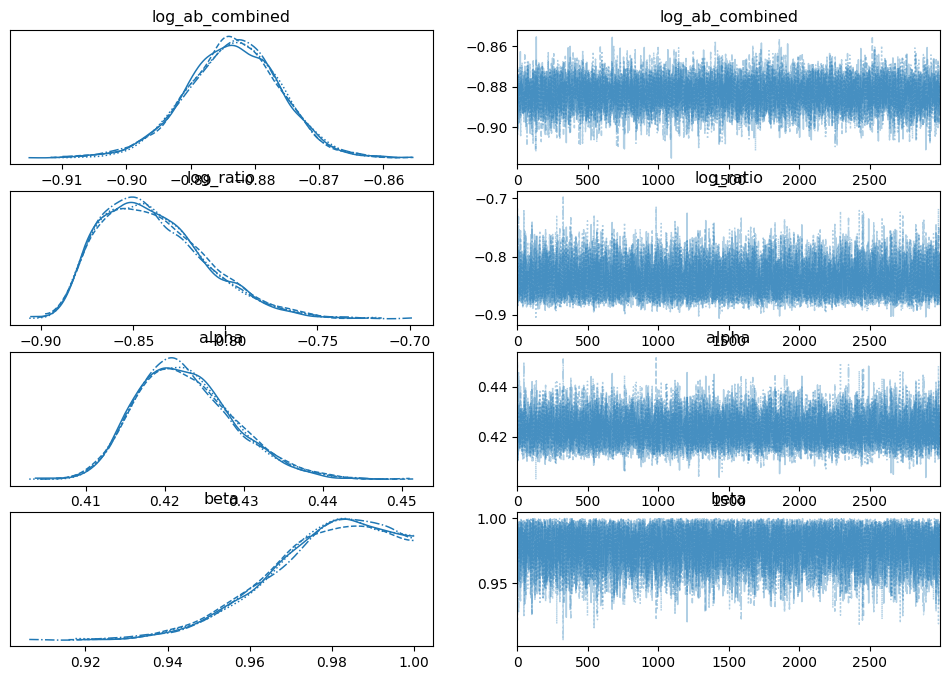

In [7]:
import arviz as az


print(az.summary(idata))
az.plot_trace(idata)

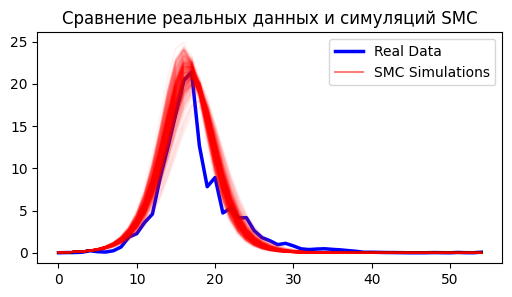

In [24]:
import matplotlib.pyplot as plt
# 1. Извлекаем цепочки параметров и превращаем их в плоские массивы
alphas_sampled = idata.posterior["alpha"].values.reshape(-1)
betas_sampled = idata.posterior["beta"].values.reshape(-1)

# 2. Строим реальные данные (синяя линия)
plt.figure(figsize=(6, 3))
plt.plot(plot_data[:, 0] * coef_array_data, label="Real Data", color="blue", linewidth=2.5)

# 3. Накладываем симуляции из апостериорного распределения
# Берем каждую 200-ю точку из 8000 полученных частиц для красивого визуального облака
step_size = len(alphas_sampled) // 300  # Нарисует ~40 кривых
for i in range(0, len(alphas_sampled), step_size):
    a_val = alphas_sampled[i]
    b_val = betas_sampled[i]
    
    # Запускаем вашу функцию симуляции напрямую для конкретной пары параметров
    sim_curve = simulation_func(_,[a_val], [b_val]) 
    
    # Визуализируем с прозрачностью (alpha=0.2), чтобы получилось красивое облако неопределенности
    plt.plot(sim_curve * coef_array_data, color="red", alpha=0.05)

# Добавляем один фиктивный график для легенды
plt.plot([], [], color="red", alpha=0.5, label="SMC Simulations")
plt.legend()
plt.title("Сравнение реальных данных и симуляций SMC")
plt.show()

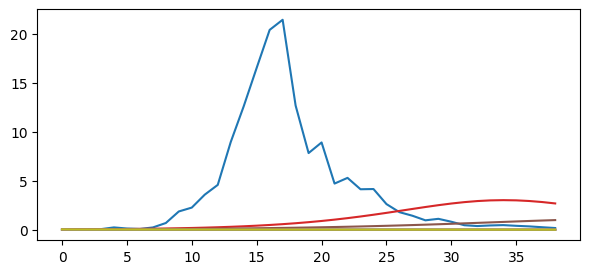

In [75]:
import matplotlib.pyplot as plt
plt.subplots(1,1,figsize=(7, 3))
plt.plot(plot_data[:, 0] * coef_array_data)
i = 3

for a,b in zip(At[:i], Bt[:i]):
    r = simulation_func(_, a.ravel(), b.ravel(), size=None)
for k in idata.posterior_predictive.sim.values.reshape(-1, 39)[::1000]:
    plt.plot( k* coef_array_data);

In [ ]:
0.42*0.98

0.41159999999999997

In [ ]:
alpha[0]        0.498  0.051   0.392    0.582      0.003    0.002     425.0   
beta[0]         0.490  0.050   0.403    0.588      0.002    0.002     416.0   
ab_combined[0]  0.987  0.012   0.962    1.000      0.001    0.001     398.0   
prop_a          0.504 

In [76]:
import math
math.sqrt(0.987*0.5) * math.sqrt(0.987*0.5)/0.5

0.987

In [ ]:
pm.math.sqrt(ab_combined * prop_a))
        beta = pm.Deterministic("beta", alpha/prop_a

0.4935

Папка уже существует: report_rscf/2026_09_09\mcmc
clean


Multiprocess sampling (6 chains in 4 jobs)
DEMetropolisZ: [alpha, beta]
Sampling 6 chains for 500 tune and 100 draw iterations (3_000 + 600 draws total) took 24 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [sim]


<xarray.Dataset> Size: 19kB
Dimensions:      (alpha_dim_0: 1, samples: 600, beta_dim_0: 1)
Coordinates:
  * alpha_dim_0  (alpha_dim_0) int32 4B 0
  * samples      (samples) object 5kB MultiIndex
  * draw         (samples) int32 2kB 0 0 0 0 0 0 1 1 ... 98 98 99 99 99 99 99 99
  * chain        (samples) int32 2kB 0 1 2 3 4 5 0 1 2 3 ... 2 3 4 5 0 1 2 3 4 5
  * beta_dim_0   (beta_dim_0) int32 4B 0
Data variables:
    alpha        (alpha_dim_0, samples) float64 5kB 0.4178 0.6215 ... 0.423
    beta         (beta_dim_0, samples) float64 5kB 0.9881 0.6163 ... 0.9742
Attributes:
    created_at:                 2026-09-08T22:19:22.384758+00:00
    arviz_version:              0.23.4
    inference_library:          pymc
    inference_library_version:  5.25.1
    sampling_time:              23.898451328277588
    tuning_steps:               500
           mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
alpha[0]  0.451  0.060   0.412    0.587      0.023    0.020       7.0   
beta[0]  

Multiprocess sampling (6 chains in 4 jobs)
DEMetropolisZ: [alpha, beta]
Sampling 6 chains for 500 tune and 100 draw iterations (3_000 + 600 draws total) took 21 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [sim]


<xarray.Dataset> Size: 19kB
Dimensions:      (alpha_dim_0: 1, samples: 600, beta_dim_0: 1)
Coordinates:
  * alpha_dim_0  (alpha_dim_0) int32 4B 0
  * samples      (samples) object 5kB MultiIndex
  * draw         (samples) int32 2kB 0 0 0 0 0 0 1 1 ... 98 98 99 99 99 99 99 99
  * chain        (samples) int32 2kB 0 1 2 3 4 5 0 1 2 3 ... 2 3 4 5 0 1 2 3 4 5
  * beta_dim_0   (beta_dim_0) int32 4B 0
Data variables:
    alpha        (alpha_dim_0, samples) float64 5kB 0.424 0.4957 ... 0.4149
    beta         (beta_dim_0, samples) float64 5kB 0.9726 0.8126 ... 0.9941
Attributes:
    created_at:                 2026-09-08T22:19:49.051368+00:00
    arviz_version:              0.23.4
    inference_library:          pymc
    inference_library_version:  5.25.1
    sampling_time:              21.439523935317993
    tuning_steps:               500
           mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
alpha[0]  0.423  0.014   0.413    0.439      0.004    0.006       7.0   
beta[0]  

...

<xarray.Dataset> Size: 19kB
Dimensions:      (alpha_dim_0: 1, samples: 600, beta_dim_0: 1)
Coordinates:
  * alpha_dim_0  (alpha_dim_0) int32 4B 0
  * samples      (samples) object 5kB MultiIndex
  * draw         (samples) int32 2kB 0 0 0 0 0 0 1 1 ... 98 98 99 99 99 99 99 99
  * chain        (samples) int32 2kB 0 1 2 3 4 5 0 1 2 3 ... 2 3 4 5 0 1 2 3 4 5
  * beta_dim_0   (beta_dim_0) int32 4B 0
Data variables:
    alpha        (alpha_dim_0, samples) float64 5kB 0.6171 0.4607 ... 0.4427
    beta         (beta_dim_0, samples) float64 5kB 0.617 0.8928 ... 0.9265
Attributes:
    created_at:                 2026-09-08T22:22:32.688722+00:00
    arviz_version:              0.23.4
    inference_library:          pymc
    inference_library_version:  5.25.1
    sampling_time:              18.567830801010132
    tuning_steps:               500
           mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
alpha[0]  0.474  0.056   0.414    0.591      0.021    0.017       7.0   
beta[0]  

Multiprocess sampling (6 chains in 4 jobs)
DEMetropolisZ: [alpha, beta]
Sampling 6 chains for 500 tune and 100 draw iterations (3_000 + 600 draws total) took 19 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [sim]


<xarray.Dataset> Size: 19kB
Dimensions:      (alpha_dim_0: 1, samples: 600, beta_dim_0: 1)
Coordinates:
  * alpha_dim_0  (alpha_dim_0) int32 4B 0
  * samples      (samples) object 5kB MultiIndex
  * draw         (samples) int32 2kB 0 0 0 0 0 0 1 1 ... 98 98 99 99 99 99 99 99
  * chain        (samples) int32 2kB 0 1 2 3 4 5 0 1 2 3 ... 2 3 4 5 0 1 2 3 4 5
  * beta_dim_0   (beta_dim_0) int32 4B 0
Data variables:
    alpha        (alpha_dim_0, samples) float64 5kB 0.4122 0.4143 ... 0.8386
    beta         (beta_dim_0, samples) float64 5kB 0.9997 0.9955 ... 0.4508
Attributes:
    created_at:                 2026-09-08T22:22:56.505624+00:00
    arviz_version:              0.23.4
    inference_library:          pymc
    inference_library_version:  5.25.1
    sampling_time:              18.644773960113525
    tuning_steps:               500
           mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
alpha[0]  0.541  0.150   0.412     0.84      0.059    0.040       7.0   
beta[0] 

Multiprocess sampling (6 chains in 4 jobs)
DEMetropolisZ: [alpha, beta]
Sampling 6 chains for 500 tune and 100 draw iterations (3_000 + 600 draws total) took 19 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [sim]


<xarray.Dataset> Size: 19kB
Dimensions:      (alpha_dim_0: 1, samples: 600, beta_dim_0: 1)
Coordinates:
  * alpha_dim_0  (alpha_dim_0) int32 4B 0
  * samples      (samples) object 5kB MultiIndex
  * draw         (samples) int32 2kB 0 0 0 0 0 0 1 1 ... 98 98 99 99 99 99 99 99
  * chain        (samples) int32 2kB 0 1 2 3 4 5 0 1 2 3 ... 2 3 4 5 0 1 2 3 4 5
  * beta_dim_0   (beta_dim_0) int32 4B 0
Data variables:
    alpha        (alpha_dim_0, samples) float64 5kB 0.6495 0.4379 ... 0.4145
    beta         (beta_dim_0, samples) float64 5kB 0.588 0.9261 ... 0.9948
Attributes:
    created_at:                 2026-09-08T22:23:20.241412+00:00
    arviz_version:              0.23.4
    inference_library:          pymc
    inference_library_version:  5.25.1
    sampling_time:              18.557836771011353
    tuning_steps:               500
           mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
alpha[0]  0.476  0.070   0.414    0.646      0.027    0.023       7.0   
beta[0]  

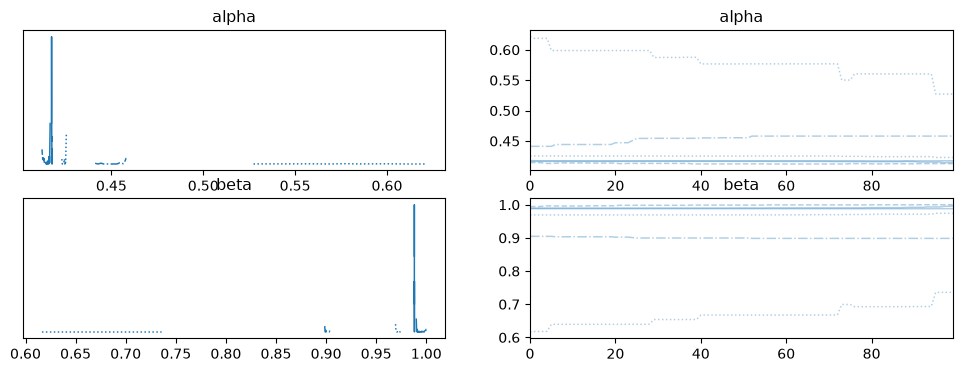

<Figure size 1200x440 with 0 Axes>

<Figure size 1200x440 with 0 Axes>

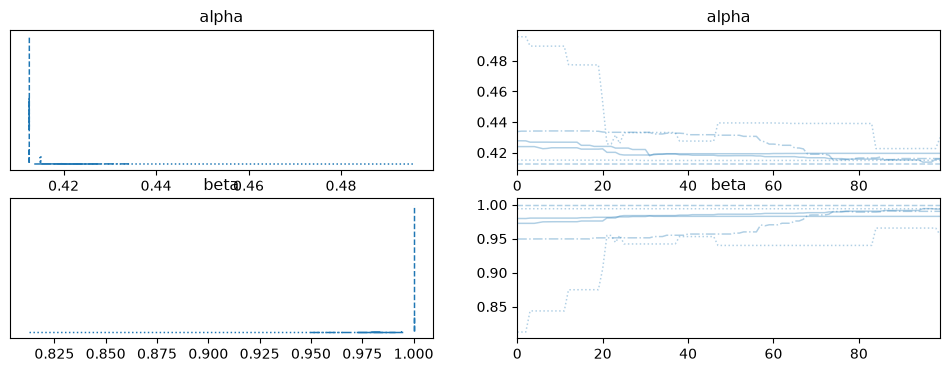

<Figure size 1200x440 with 0 Axes>

<Figure size 1200x440 with 0 Axes>

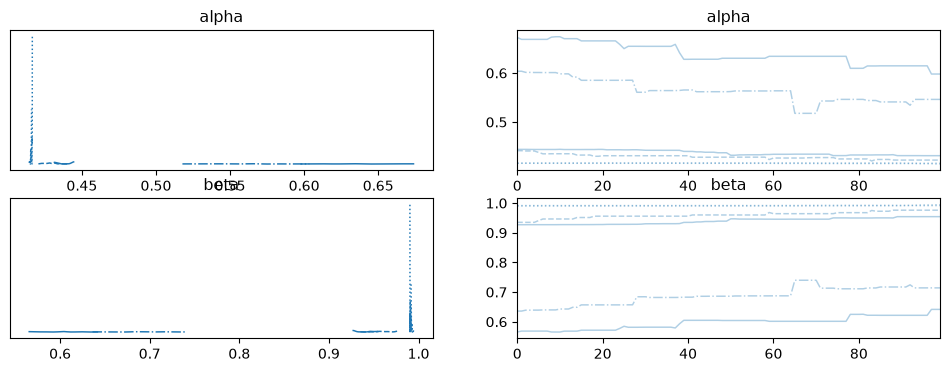

<Figure size 1200x440 with 0 Axes>

<Figure size 1200x440 with 0 Axes>

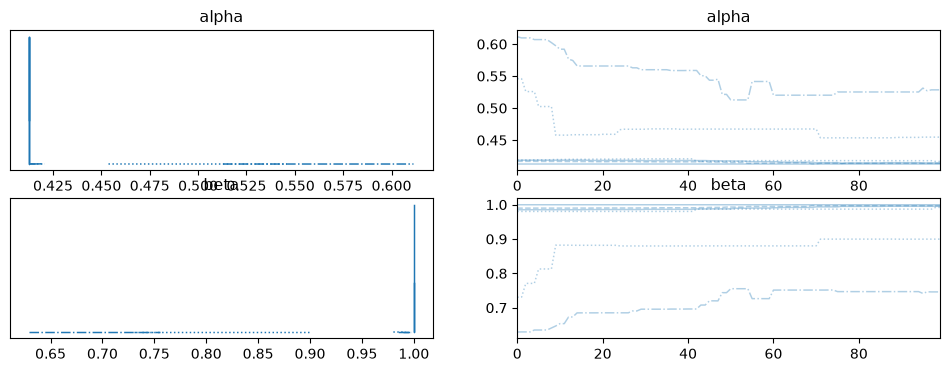

<Figure size 1200x440 with 0 Axes>

<Figure size 1200x440 with 0 Axes>

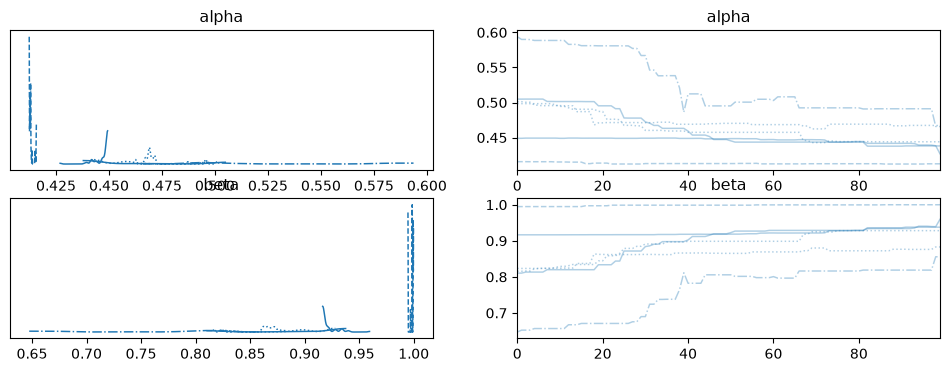

<Figure size 1200x440 with 0 Axes>

<Figure size 1200x440 with 0 Axes>

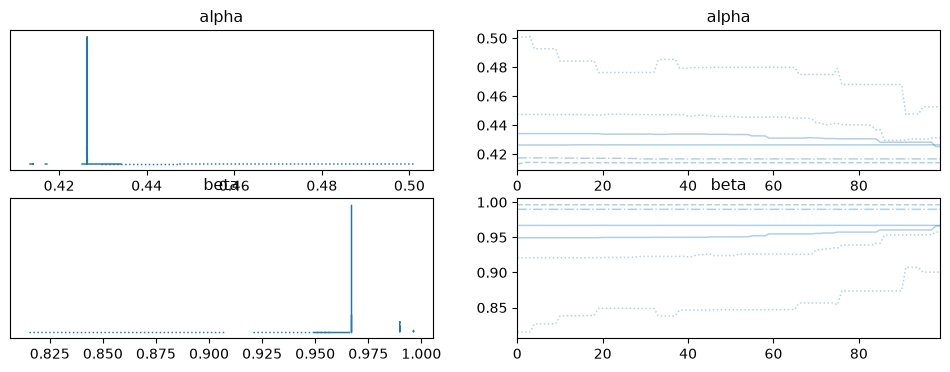

<Figure size 1200x440 with 0 Axes>

<Figure size 1200x440 with 0 Axes>

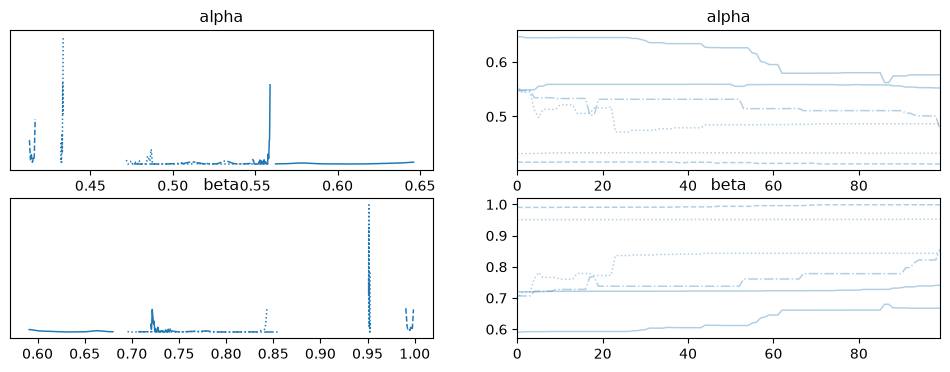

<Figure size 1200x440 with 0 Axes>

<Figure size 1200x440 with 0 Axes>

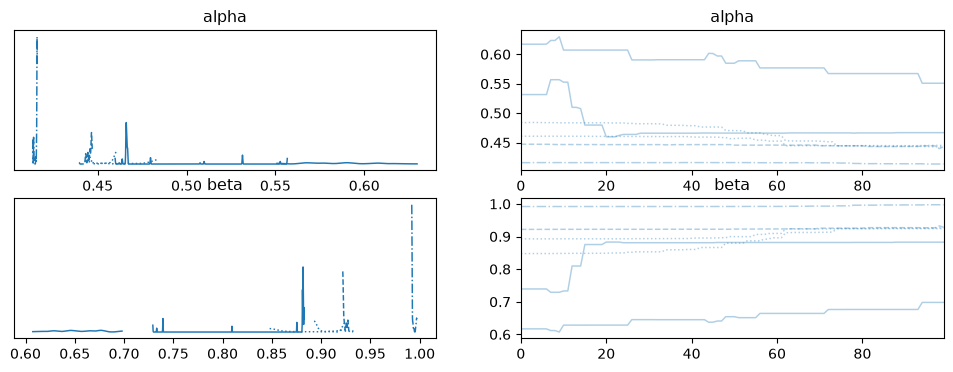

<Figure size 1200x440 with 0 Axes>

<Figure size 1200x440 with 0 Axes>

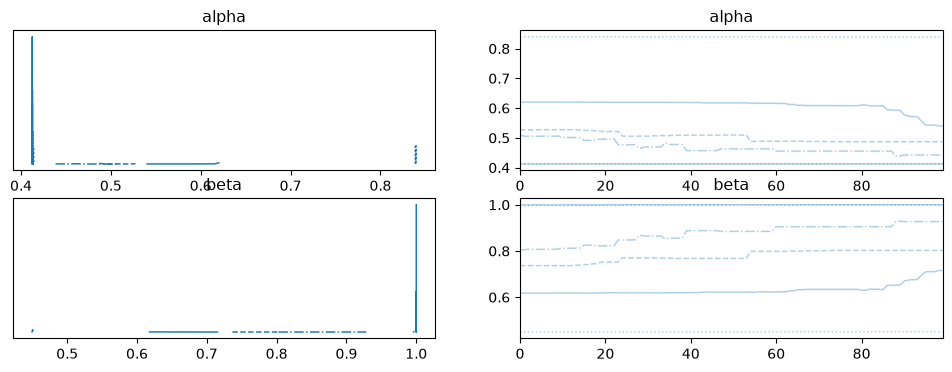

<Figure size 1200x440 with 0 Axes>

<Figure size 1200x440 with 0 Axes>

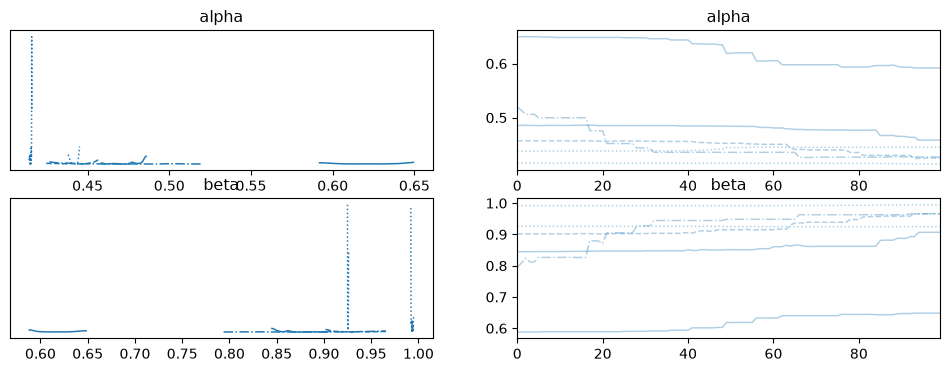

<Figure size 1200x440 with 0 Axes>

<Figure size 1200x440 with 0 Axes>

In [ ]:
# alpha*beta
method = 'mcmc'
type = 'total'
eps = 2


forecast_duration = 4
predictor.generate_forecasts(method=method,
                             type=type,
                             forecast_duration=forecast_duration,
                             epsilon_start=eps,
                             epsilon_end=eps,
                             epsilon_step=1,
                             n_trials=10,
                             sample=300, # choosing N lines for the final plot?
                             tune=500,#1000
                             draws=100,#1000
                             chains=6)# 6 from Dinara's ipynb

Папка уже существует: report_rscf/2026_09_08\mcmc


Only 1 samples per chain. Reliable r-hat and ESS diagnostics require longer chains for accurate estimate.
Sequential sampling (1 chains in 1 job)
DEMetropolisZ: [alpha, beta]
Sampling 1 chain for 1 tune and 1 draw iterations (1 + 1 draws total) took 0 seconds.
The number of samples is too small to check convergence reliably.
Sampling: [sim]
c:\Users\105\GitHub\Influenza_bulletin\.venv\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\105\GitHub\Influenza_bulletin\.venv\Lib\site-packages\numpy\core\_methods.py:195: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
c:\Users\105\GitHub\Influenza_bulletin\.venv\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\105\GitHub\Influenza_bulletin\.venv\Lib\site-packages\numpy\core\_methods.py:19

<xarray.Dataset> Size: 40B
Dimensions:      (alpha_dim_0: 1, samples: 1, beta_dim_0: 1)
Coordinates:
  * alpha_dim_0  (alpha_dim_0) int32 4B 0
  * samples      (samples) object 8B MultiIndex
  * draw         (samples) int32 4B 0
  * chain        (samples) int32 4B 0
  * beta_dim_0   (beta_dim_0) int32 4B 0
Data variables:
    alpha        (alpha_dim_0, samples) float64 8B 0.5006
    beta         (beta_dim_0, samples) float64 8B 0.4993
Attributes:
    created_at:                 2026-09-08T19:43:09.694826+00:00
    arviz_version:              0.23.4
    inference_library:          pymc
    inference_library_version:  5.25.1
    sampling_time:              0.06835389137268066
    tuning_steps:               1
           mean  sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
alpha[0]  0.501 NaN   0.501    0.501        NaN      NaN       NaN       NaN   
beta[0]   0.499 NaN   0.499    0.499        NaN      NaN       NaN       NaN   

          r_hat  
alpha[0]    NaN  
beta[0

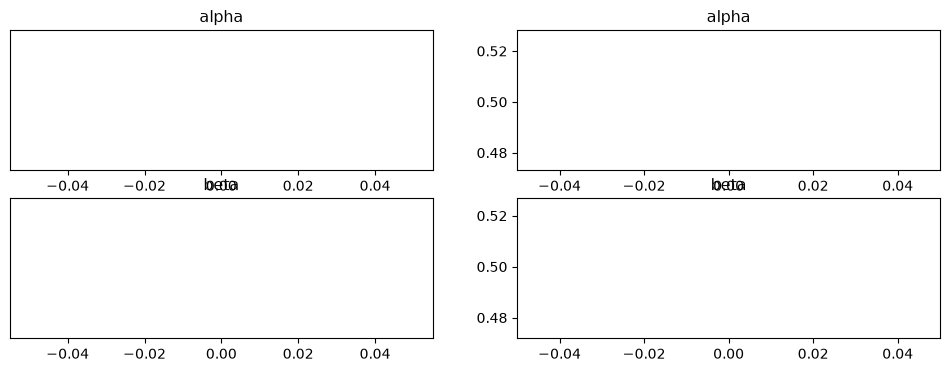

<Figure size 1200x440 with 0 Axes>

<Figure size 1200x440 with 0 Axes>

In [ ]:
# alpha*beta
method = 'mcmc'
type = 'total'
eps = 2.1

#ess_bulk (7.0 - 10.0): Из всех ваших тысяч шагов сэмплер выдал информацию, эквивалентную всего 7-10 независимым точкам. Это катастрофически мало для оценки среднего значения.

forecast_duration = 4
predictor.generate_forecasts(method=method,
                             type=type,
                             forecast_duration=forecast_duration,
                             epsilon_start=eps,
                             epsilon_end=eps,
                             epsilon_step=1,
                             n_trials=1,
                             sample=1, # choosing N lines for the final plot?
                             tune=1,#1000
                             draws=1,#1000
                             chains=1)# 6 from Dinara's ipynb

In [ ]:
from plot_module.calibration.calibration_and_forecast import calculate_coefficients, prepare_calibration_data,get_model_and_function
coef_array_data, coef_array_forecast, coef_array_all = calculate_coefficients(epid_data, 4)
model, model_params, func_to_get_newly_data = get_model_and_function(epid_data, type)
data, dur, plot_data = prepare_calibration_data(epid_data, type)


In [ ]:
import numpy as np
coef_array_data = np.array(10000 / epid_data.returned_df["total_population"])
coef_array_data

array([0.00018175, 0.00018175, 0.00018175, 0.00018175, 0.00018174,
       0.00018177, 0.00018177, 0.00018177, 0.00018177, 0.00018177,
       0.00018177, 0.00018177, 0.00018177, 0.00018177, 0.00018177,
       0.00018177, 0.00018177, 0.00018177, 0.00018177, 0.00018177,
       0.00018157, 0.00018157, 0.00018157, 0.00018157, 0.00018157,
       0.00018157, 0.00018157, 0.00018157, 0.00018157, 0.00018156,
       0.00018156, 0.00018156, 0.00018156, 0.00018156, 0.00018156,
       0.00018156, 0.00018156, 0.00018156, 0.00018156])

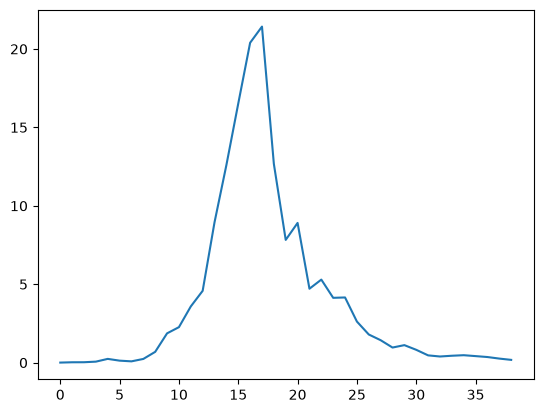

In [ ]:

import matplotlib.pyplot as plt
plt.plot(plot_data[:, 0] * coef_array_data)

In [ ]:
"""
Decisive diagnostic for a 2-parameter epidemic blackbox:
brute-force grid scan over the FULL prior box to answer:
  (A) Does ANY (alpha, beta) reproduce the observed wave?
  (B) If yes: where is the good region, and what epsilon should be?
  (C) If no: the model is structurally wrong - fix the model, not the sampler.

Plug your simulator into run_model() and your data into Y_OBS, then: python grid_scan.py
"""
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

from model_complex.models import Model
from model_complex.utils import ModelParams

simulate_params = ModelParams(
            alpha=[0],
            beta=[0],
            population_size=model_params.population_size,
            initial_infectious=model_params.initial_infectious,
        )
time_step='week'
alpha_dim, beta_dim = model.params()
duration = len(data) // alpha_dim
get_newly_infected_base_on_time_step = model.get_daily_newly_infected

if time_step == "week":
    duration *= 7
    get_newly_infected_base_on_time_step = model.get_weekly_newly_infected




# ================== PLUG YOUR STUFF HERE ==================
def run_model(alpha, beta):
    """DETERMINISTIC simulator run: no rng noise, no epsilon.
    Must return a 1-D array of the same length as Y_OBS.
    Example placeholder (replace with your blackbox):"""

    simulate_params.alpha = [alpha]
    simulate_params.beta = [beta]

    model.simulate(params=simulate_params, modeling_duration=duration)

    return get_newly_infected_base_on_time_step()*coef_array_data

Y_OBS = plot_data[:, 0] * coef_array_data  # <- your 38 observations. Placeholder if None:

# ===========================================================

Y_OBS = np.asarray(Y_OBS, dtype=float)
T = len(Y_OBS)

NA, NB = 100, 100
A = np.linspace(0.3, 0.99, NA)
B = np.linspace(0.3, 0.99, NB)
RMS = np.full((NA, NB), np.nan)

best_rms, best_ab, best_curve = np.inf, None, None
for i, a in enumerate(A):
    for j, b in enumerate(B):
        
        c = np.asarray(run_model(a, b), dtype=float)
        if c.shape != (T,) or not np.all(np.isfinite(c)):
            continue
        r = float(np.sqrt(np.mean((c - Y_OBS) ** 2)))
        RMS[i, j] = r
        if r < best_rms:
            best_rms, best_ab, best_curve = r, (a, b), c



Failed to reload module 'cutils_ext' from file 'C:\Users\105\AppData\Local\PyTensor\compiledir_Windows-11-10.0.26200-SP0-AMD64_Family_25_Model_117_Stepping_2_AuthenticAMD-3.12.7-64\cutils_ext\__init__.py'
Traceback (most recent call last):
  File "c:\Users\105\GitHub\Influenza_bulletin\.venv\Lib\site-packages\IPython\extensions\autoreload.py", line 326, in check
    superreload(m, reload, self.old_objects)
  File "c:\Users\105\GitHub\Influenza_bulletin\.venv\Lib\site-packages\IPython\extensions\autoreload.py", line 580, in superreload
    module = reload(module)
             ^^^^^^^^^^^^^^
  File "D:\Programs\Anaconda\Lib\importlib\__init__.py", line 130, in reload
    raise ModuleNotFoundError(f"spec not found for the module {name!r}", name=name)
ModuleNotFoundError: spec not found for the module 'cutils_ext'
[autoreload of cutils_ext failed: Traceback (most recent call last):
  File "c:\Users\105\GitHub\Influenza_bulletin\.venv\Lib\site-packages\IPython\extensions\autoreload.py", lin

grid: 100 x 100 = 10000 runs
BEST fit: alpha=0.418 beta=0.983  RMS=2.102  R^2=0.860
-> recommended epsilon ~ 2.10
fraction of the (alpha,beta) box with RMS < 2*best: 0.0141
   (tiny fraction = needle-in-haystack: samplers WILL struggle, use SMC + that epsilon)

top-10 grid points:
   alpha=0.418 beta=0.983  RMS=2.102  R0-ish(a*b)=0.411
   alpha=0.418 beta=0.990  RMS=2.108  R0-ish(a*b)=0.414
   alpha=0.425 beta=0.969  RMS=2.190  R0-ish(a*b)=0.412
   alpha=0.425 beta=0.976  RMS=2.259  R0-ish(a*b)=0.415
   alpha=0.418 beta=0.976  RMS=2.266  R0-ish(a*b)=0.408
   alpha=0.412 beta=0.990  RMS=2.270  R0-ish(a*b)=0.407
   alpha=0.432 beta=0.955  RMS=2.302  R0-ish(a*b)=0.413
   alpha=0.425 beta=0.962  RMS=2.302  R0-ish(a*b)=0.409
   alpha=0.432 beta=0.948  RMS=2.369  R0-ish(a*b)=0.410
   alpha=0.432 beta=0.962  RMS=2.418  R0-ish(a*b)=0.416


Text(0.5, 0.98, 'GRID SCAN DIAGNOSTIC')

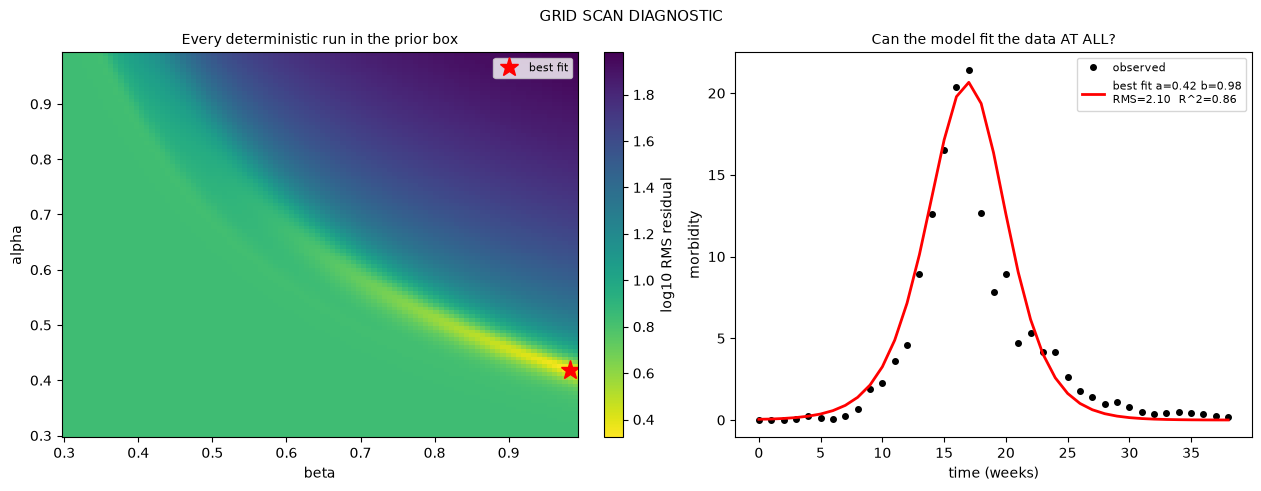

In [ ]:
ss_res = float(np.sum((best_curve - Y_OBS) ** 2))
ss_tot = float(np.sum((Y_OBS - Y_OBS.mean()) ** 2))
best_r2 = 1.0 - ss_res / ss_tot
good = RMS < 2.0 * best_rms
frac_good = good.sum() / np.isfinite(RMS).sum()

print("grid: %d x %d = %d runs" % (NA, NB, NA * NB))
print("BEST fit: alpha=%.3f beta=%.3f  RMS=%.3f  R^2=%.3f" %
      (best_ab[0], best_ab[1], best_rms, best_r2))
print("-> recommended epsilon ~ %.2f" % best_rms)
print("fraction of the (alpha,beta) box with RMS < 2*best: %.4f" % frac_good)
print("   (tiny fraction = needle-in-haystack: samplers WILL struggle, use SMC + that epsilon)")

order = np.argsort(RMS, axis=None)[:10]
print("\ntop-10 grid points:")
for k in order:
    i, j = np.unravel_index(k, RMS.shape)
    print("   alpha=%.3f beta=%.3f  RMS=%.3f  R0-ish(a*b)=%.3f" % (A[i], B[j], RMS[i, j], A[i]*B[j]))

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8), constrained_layout=True)
pc = axes[0].pcolormesh(B, A, np.log10(np.maximum(RMS, 1e-3)), cmap="viridis_r")
axes[0].plot(best_ab[1], best_ab[0], "r*", ms=14, label="best fit")
fig.colorbar(pc, ax=axes[0], label="log10 RMS residual")
axes[0].set_xlabel("beta"); axes[0].set_ylabel("alpha")


axes[0].set_title("Every deterministic run in the prior box", fontsize=10)
axes[0].legend(fontsize=8)

tt = np.arange(T)
axes[1].plot(tt, Y_OBS, "ko", ms=4, label="observed")
axes[1].plot(tt, best_curve, "r-", lw=2,
             label="best fit a=%.2f b=%.2f\nRMS=%.2f  R^2=%.2f" % (*best_ab, best_rms, best_r2))
axes[1].set_title("Can the model fit the data AT ALL?", fontsize=10)
axes[1].set_xlabel("time (weeks)"); axes[1].set_ylabel("morbidity")
axes[1].legend(fontsize=8)
fig.suptitle("GRID SCAN DIAGNOSTIC", fontsize=11)

Папка уже существует: report_rscf/2026_09_08\mcmc


Multiprocess sampling (6 chains in 4 jobs)
DEMetropolisZ: [alpha, beta]
Sampling 6 chains for 2_000 tune and 1_000 draw iterations (12_000 + 6_000 draws total) took 22 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
Sampling: [sim]


<xarray.Dataset> Size: 192kB
Dimensions:      (alpha_dim_0: 1, samples: 6000, beta_dim_0: 1)
Coordinates:
  * alpha_dim_0  (alpha_dim_0) int32 4B 0
  * samples      (samples) object 48kB MultiIndex
  * draw         (samples) int32 24kB 0 0 0 0 0 0 1 ... 999 999 999 999 999 999
  * chain        (samples) int32 24kB 0 1 2 3 4 5 0 1 2 3 ... 3 4 5 0 1 2 3 4 5
  * beta_dim_0   (beta_dim_0) int32 4B 0
Data variables:
    alpha        (alpha_dim_0, samples) float64 48kB 0.001848 ... 0.09639
    beta         (beta_dim_0, samples) float64 48kB 0.5353 0.5747 ... 0.2079
Attributes:
    created_at:                 2026-09-08T19:49:34.100777+00:00
    arviz_version:              0.23.4
    inference_library:          pymc
    inference_library_version:  5.25.1
    sampling_time:              21.796555995941162
    tuning_steps:               2000
           mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
alpha[0]  0.512  0.289   0.074    1.000       0.01    0.005     716.0   
beta[0] 

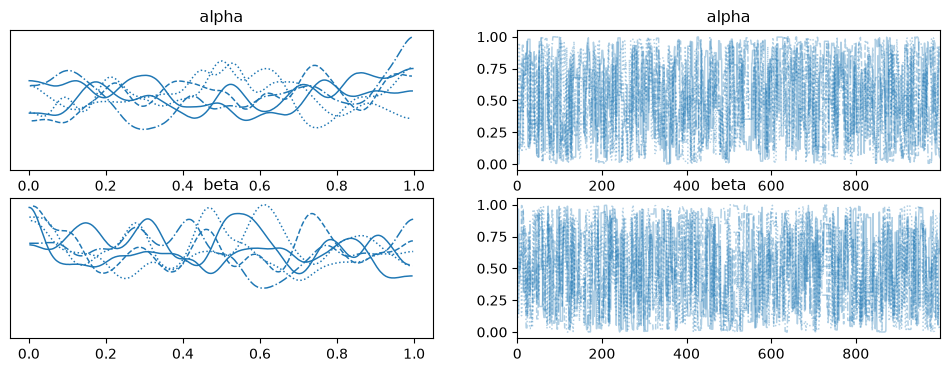

<Figure size 1200x440 with 0 Axes>

<Figure size 1200x440 with 0 Axes>

In [ ]:
# alpha*beta
method = 'mcmc'
type = 'total'
eps = 1


forecast_duration = 4
predictor.generate_forecasts(method=method,
                             type=type,
                             forecast_duration=forecast_duration,
                             epsilon_start=eps,
                             epsilon_end=eps,
                             epsilon_step=1,
                             n_trials=1,
                             sample=300, # choosing N lines for the final plot?
                             tune=2000,#1000
                             draws=1000,#1000
                             chains=6)# 6 from Dinara's ipynb

Failed to reload module 'cutils_ext' from file 'C:\Users\105\AppData\Local\PyTensor\compiledir_Windows-11-10.0.26200-SP0-AMD64_Family_25_Model_117_Stepping_2_AuthenticAMD-3.12.7-64\cutils_ext\__init__.py'
Traceback (most recent call last):
  File "c:\Users\105\GitHub\Influenza_bulletin\.venv\Lib\site-packages\IPython\extensions\autoreload.py", line 326, in check
    superreload(m, reload, self.old_objects)
  File "c:\Users\105\GitHub\Influenza_bulletin\.venv\Lib\site-packages\IPython\extensions\autoreload.py", line 580, in superreload
    module = reload(module)
             ^^^^^^^^^^^^^^
  File "D:\Programs\Anaconda\Lib\importlib\__init__.py", line 130, in reload
    raise ModuleNotFoundError(f"spec not found for the module {name!r}", name=name)
ModuleNotFoundError: spec not found for the module 'cutils_ext'
[autoreload of cutils_ext failed: Traceback (most recent call last):
  File "c:\Users\105\GitHub\Influenza_bulletin\.venv\Lib\site-packages\IPython\extensions\autoreload.py", lin

Папка уже существует: report_rscf/2026_09_08\mcmc


Multiprocess sampling (10 chains in 4 jobs)
DEMetropolisZ: [alpha, beta]
Sampling 10 chains for 2_000 tune and 500 draw iterations (20_000 + 5_000 draws total) took 36 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [sim]


<xarray.Dataset> Size: 160kB
Dimensions:      (alpha_dim_0: 1, samples: 5000, beta_dim_0: 1)
Coordinates:
  * alpha_dim_0  (alpha_dim_0) int32 4B 0
  * samples      (samples) object 40kB MultiIndex
  * draw         (samples) int32 20kB 0 0 0 0 0 0 0 ... 499 499 499 499 499 499
  * chain        (samples) int32 20kB 0 1 2 3 4 5 6 7 8 9 ... 1 2 3 4 5 6 7 8 9
  * beta_dim_0   (beta_dim_0) int32 4B 0
Data variables:
    alpha        (alpha_dim_0, samples) float64 40kB 0.1923 0.5331 ... 0.8
    beta         (beta_dim_0, samples) float64 40kB 0.1685 0.1371 ... 0.7384
Attributes:
    created_at:                 2026-09-08T19:46:56.054047+00:00
    arviz_version:              0.23.4
    inference_library:          pymc
    inference_library_version:  5.25.1
    sampling_time:              36.08564066886902
    tuning_steps:               2000
           mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
alpha[0]  0.521  0.285   0.020    0.950      0.010    0.005     733.0   
beta[0] 

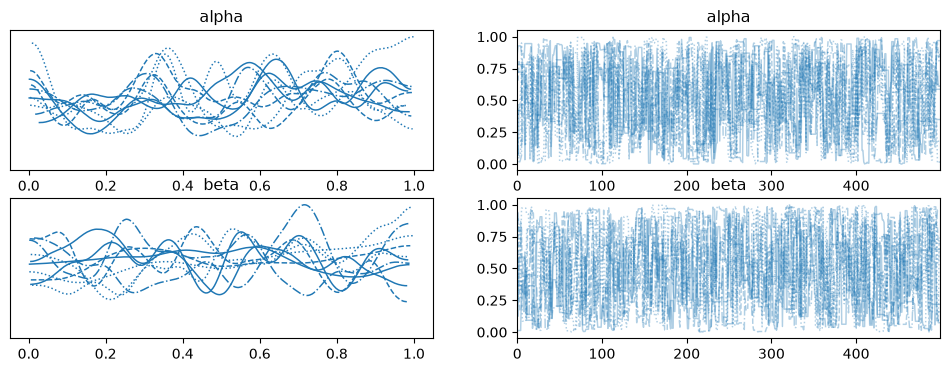

<Figure size 1200x440 with 0 Axes>

<Figure size 1200x440 with 0 Axes>

In [ ]:
method = 'mcmc'
type = 'total'
eps = 10

forecast_duration = 4
predictor.generate_forecasts(method=method,
                             type=type,
                             forecast_duration=forecast_duration,
                             epsilon_start=eps,
                             epsilon_end=eps,
                             epsilon_step=1,
                             n_trials=1,
                             sample=600, # choosing N lines for the final plot?
                             tune=2000,#1000
                             draws=500,#1000
                             chains=10)# 6 from Dinara's ipynb

In [ ]:
city = 'russia'
save_path_folder='report_rscf/'
epid_data = InfluenzaData(city, begin_year=2025, begin_week=40, end_year=2025, end_week=49)

predictor = PredictionGenerator(epid_data=epid_data,
                                city=city,
                                save_path=save_path_folder)

In [ ]:
epid_data.cases_df.iloc[-1]

datetime                  2025-11-24 00:00:00
region_name                                РФ
district_name                              РФ
sars_total_cases                       432561
sars_cases_age_group_0                  41265
sars_cases_age_group_1                  71891
sars_cases_age_group_2                 118355
sars_cases_age_group_4                 182567
sars_cases_age_group_5                  18483
total_population                     55014040
population_age_group_0                1493462
population_age_group_1                2332343
population_age_group_2                5246924
population_age_group_4               36568656
population_age_group_5                9372655
sars_cases_age_group_3                 201050
population_age_group_3               45941311
rel_strain_0                         0.019813
real_cases_strain_0                    8570.0
rel_strain_1                         0.007655
real_cases_strain_1                    3311.0
rel_strain_2                      

In [ ]:
method = 'annealing'
type = 'total'
forecast_duration = 10
predictor.generate_forecasts(method=method,
                             type=type,
                             forecast_duration=forecast_duration,
                             epsilon_start=10,
                             epsilon_end=10,
                             epsilon_step=100,
                             n_trials=1)

Создана папка: ./dinara/report_rscf/2025_12_03_12_57_26\annealing
[[   280.74507912    480.85375592    939.19407791   1842.11127158
    3608.70198117   7049.0594873   13691.49766142  26302.18169702
   49471.14053104  89421.20144053 150408.49847507 224019.97069291
  277658.58658449 271893.19496146 208303.49827117 130171.06782997
   70908.84494993  35693.89309126  17245.02489607]]
[  707.   463.  1307.  3795. 10390. 12575. 19803. 25022. 47876.]
[0.12851265 0.08416033 0.23757572 0.68982391 1.8886088  2.28578014
 3.59962657 4.54829349 8.70250576]


<Figure size 1200x440 with 0 Axes>